Cellule 1 — Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("✅ Librairies chargées avec succès")

✅ Librairies chargées avec succès


Cellule 2 — Chargement des données

In [2]:
# ⚠️ sep=";" et encoding="latin-1" sont obligatoires pour ce fichier
df = pd.read_csv(
    "../data/online_retail_clean.csv",
    sep=";",
    encoding="latin-1"
)

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

✅ Dataset chargé : 541,909 lignes × 8 colonnes


Cellule 3 — Aperçu des premières lignes

In [3]:
print("APERÇU DES PREMIÈRES LIGNES")
df.head(10)

APERÇU DES PREMIÈRES LIGNES


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/01/2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/01/2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/01/2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/01/2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/01/2010 08:34,1.69,13047.0,United Kingdom


Cellule 4 — Structure du dataset

In [4]:
print("STRUCTURE DU DATASET")
df.info()

STRUCTURE DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


Cellule 5 — Statistiques descriptives

In [5]:
print("STATISTIQUES DESCRIPTIVES")
df.describe()

STATISTIQUES DESCRIPTIVES


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


 Cellule 6 — Valeurs manquantes

In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Valeurs manquantes" : missing,
    "Pourcentage (%)"    : missing_pct
})

missing_df = missing_df[missing_df["Valeurs manquantes"] > 0]
print(missing_df)
print(f"\n👉 {missing_df['Valeurs manquantes'].sum():,} valeurs manquantes au total")

             Valeurs manquantes  Pourcentage (%)
Description                1454             0.27
CustomerID               135080            24.93

👉 136,534 valeurs manquantes au total


Cellule 7 — Doublons

In [7]:
nb_doublons = df.duplicated().sum()

print(f"Nombre de lignes dupliquées : {nb_doublons:,}")

if nb_doublons > 0:
    print("⚠️  Des doublons existent — à traiter à l'Étape 2")
else:
    print("✅ Aucun doublon détecté")

Nombre de lignes dupliquées : 5,268
⚠️  Des doublons existent — à traiter à l'Étape 2


Cellule 8 — Création de TotalPrice

In [8]:
# Colonne métier clé : chiffre d'affaires par ligne
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("✅ Colonne 'TotalPrice' créée (Quantity × UnitPrice)\n")
df[["InvoiceNo", "Description", "Quantity", "UnitPrice", "TotalPrice"]].head(8)

✅ Colonne 'TotalPrice' créée (Quantity × UnitPrice)



,InvoiceNo,Description,Quantity,UnitPrice,TotalPrice
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34
5,536365,SET 7 BABUSHKA NESTING BOXES,2,7.65,15.30
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,25.50
7,536366,HAND WARMER UNION JACK,6,1.85,11.10


Cellule 9 — Aperçu business

In [9]:
ca_total     = df["TotalPrice"].sum()
nb_commandes = df["InvoiceNo"].nunique()
nb_clients   = df["CustomerID"].nunique()
nb_produits  = df["StockCode"].nunique()
nb_pays      = df["Country"].nunique()

print(f"💰 Chiffre d'affaires total  : £{ca_total:>15,.2f}")
print(f"📦 Nombre de commandes       : {nb_commandes:>15,}")
print(f"👤 Nombre de clients uniques : {nb_clients:>15,}")
print(f"🛍️  Nombre de produits        : {nb_produits:>15,}")
print(f"🌍 Nombre de pays             : {nb_pays:>15,}")
print()
print("⚠️  Note : le CA inclut les retours — on les traitera à l'Étape 2")

💰 Chiffre d'affaires total  : £   9,747,747.93
📦 Nombre de commandes       :          25,900
👤 Nombre de clients uniques :           4,372
🛍️  Nombre de produits        :           4,070
🌍 Nombre de pays             :              38

⚠️  Note : le CA inclut les retours — on les traitera à l'Étape 2


Cellule 10 — Sauvegarde du dataset brut

In [10]:
# On garde une copie du brut avant tout nettoyage
# Bonne pratique : toujours travailler sur une copie
df_raw = df.copy()

print(f"Dataset brut sauvegardé : {df_raw.shape[0]:,} lignes")
print(f"Dataset de travail      : {df.shape[0]:,} lignes")

Dataset brut sauvegardé : 541,909 lignes
Dataset de travail      : 541,909 lignes


Cellule 11 — Suppression des doublons

In [11]:
avant = len(df)
df = df.drop_duplicates()
apres = len(df)

print(f"Doublons supprimés : {avant - apres:,} lignes")
print(f"Dataset après      : {apres:,} lignes")

Doublons supprimés : 5,268 lignes
Dataset après      : 536,641 lignes


Cellule 12 — Valeurs manquantes

In [12]:
# Description manquante (1 454 lignes) → on supprime
# CustomerID manquant (135 080 lignes) → on garde mais on flag
avant = len(df)
df = df.dropna(subset=["Description"])
print(f"Lignes sans Description supprimées : {avant - len(df):,}")

# CustomerID : on crée un flag pour savoir si le client est connu
df["ClientConnu"] = df["CustomerID"].notna()
print(f"\nClients connus   : {df['ClientConnu'].sum():,} lignes")
print(f"Clients inconnus : {(~df['ClientConnu']).sum():,} lignes")

Lignes sans Description supprimées : 1,454

Clients connus   : 401,604 lignes
Clients inconnus : 133,583 lignes


💡 Pourquoi on ne supprime pas les CustomerID manquants ? Parce qu'ils représentent ~25% des ventes — les supprimer fausserait le CA total. On les garde mais on les identifie.

 Cellule 13 — Suppression des retours et prix aberrants

In [13]:
avant = len(df)

# Retours : Quantity négative = annulation de commande
df = df[df["Quantity"] > 0]
print(f"Lignes avec Quantity ≤ 0 supprimées : {avant - len(df):,}")

avant = len(df)

# Prix aberrants : UnitPrice ≤ 0 = erreur ou article offert
df = df[df["UnitPrice"] > 0]
print(f"Lignes avec UnitPrice ≤ 0 supprimées : {avant - len(df):,}")

print(f"\nDataset après nettoyage : {len(df):,} lignes")

Lignes avec Quantity ≤ 0 supprimées : 9,725
Lignes avec UnitPrice ≤ 0 supprimées : 584

Dataset après nettoyage : 524,878 lignes


Cellule 14 — Conversion de la date

In [14]:
# format="mixed" → pandas détecte automatiquement les formats mélangés
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="mixed", dayfirst=True)

# On extrait des colonnes utiles pour l'analyse
df["Année"] = df["InvoiceDate"].dt.year
df["Mois"]  = df["InvoiceDate"].dt.month
df["Jour"]  = df["InvoiceDate"].dt.day_name()
df["Heure"] = df["InvoiceDate"].dt.hour

print("✅ InvoiceDate convertie en datetime")
print(f"\nPériode couverte : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
df[["InvoiceDate", "Année", "Mois", "Jour", "Heure"]].head(5)

✅ InvoiceDate convertie en datetime

Période couverte : 2010-01-12 08:26:00 → 2011-12-10 17:19:00


,InvoiceDate,Année,Mois,Jour,Heure
0,2010-01-12 08:26:00,2010,1,Tuesday,8
1,2010-01-12 08:26:00,2010,1,Tuesday,8
2,2010-01-12 08:26:00,2010,1,Tuesday,8
3,2010-01-12 08:26:00,2010,1,Tuesday,8
4,2010-01-12 08:26:00,2010,1,Tuesday,8


💡 format="mixed" dit à pandas "analyse chaque ligne individuellement" — c'est la solution quand un CSV Kaggle mélange plusieurs formats de date. dayfirst=True évite que pandas confonde jour et mois sur les dates ambiguës.

Cellule 15 — Recalcul de TotalPrice + vérification finale

In [15]:
# On recalcule TotalPrice sur le dataset propre
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("=" * 50)
print("BILAN DU NETTOYAGE")
print("=" * 50)
print(f"Lignes brutes    : {len(df_raw):,}")
print(f"Lignes propres   : {len(df):,}")
print(f"Lignes retirées  : {len(df_raw) - len(df):,}")
print(f"Données gardées  : {len(df)/len(df_raw)*100:.1f}%")
print()
print(f"💰 CA recalculé (sans retours) : £{df['TotalPrice'].sum():,.2f}")
print()
print("Valeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

BILAN DU NETTOYAGE
Lignes brutes    : 541,909
Lignes propres   : 524,878
Lignes retirées  : 17,031
Données gardées  : 96.9%

💰 CA recalculé (sans retours) : £10,642,110.80

Valeurs manquantes restantes :
CustomerID    132186
dtype: int64


Cellule 16 — CA mensuel

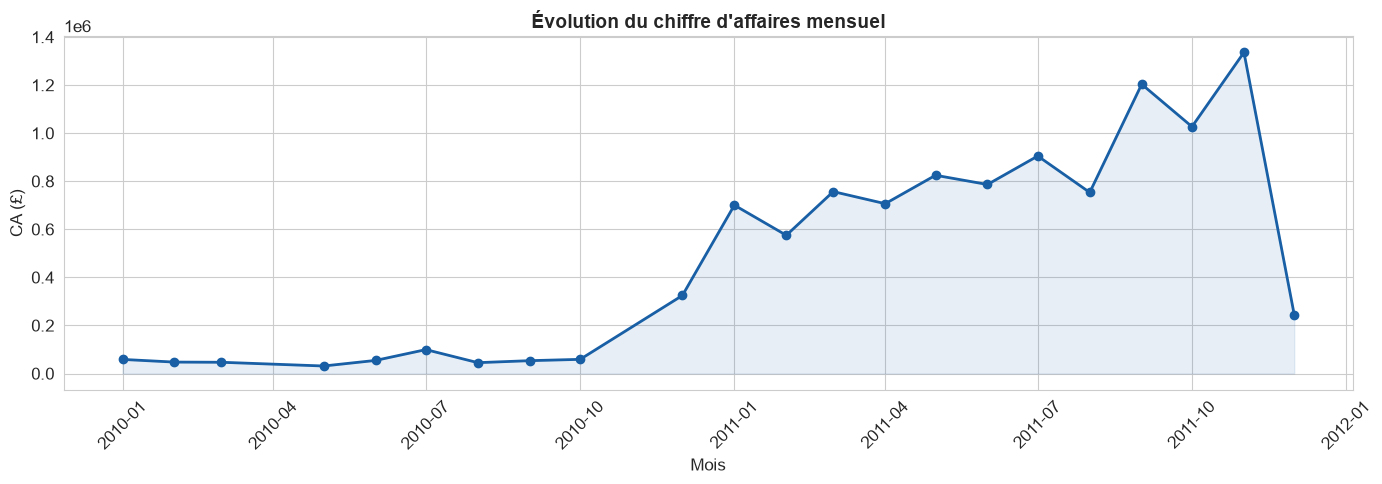

Meilleur mois  : November 2011 — £1,336,139.48
Moins bon mois : May 2010 — £31,364.63

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est idéale pour visualiser une
     évolution dans le temps (tendance + ruptures).
     L'aire colorée renforce la lecture du volume.

📝 ANALYSE MÉTIER :
   → On observe une montée progressive du CA sur
     l'année 2011, avec un pic fort en novembre.
     C'est typique du e-commerce : la période
     pré-fêtes (Black Friday, Noël) génère un
     pic de ventes important.
     Recommandation : concentrer les campagnes
     marketing et les stocks sur sept-nov.
─────────────────────────────────────────────────



In [16]:
ca_mensuel = df.groupby(["Année", "Mois"])["TotalPrice"].sum().reset_index()
ca_mensuel["Période"] = pd.to_datetime({
    "year"  : ca_mensuel["Année"],
    "month" : ca_mensuel["Mois"],
    "day"   : 1
})

plt.figure(figsize=(14, 5))
plt.plot(ca_mensuel["Période"], ca_mensuel["TotalPrice"], marker="o", color="#185FA5", linewidth=2)
plt.fill_between(ca_mensuel["Période"], ca_mensuel["TotalPrice"], alpha=0.1, color="#185FA5")
plt.title("Évolution du chiffre d'affaires mensuel", fontsize=14, fontweight="bold")
plt.xlabel("Mois")
plt.ylabel("CA (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Meilleur mois  : {ca_mensuel.loc[ca_mensuel['TotalPrice'].idxmax(), 'Période'].strftime('%B %Y')} — £{ca_mensuel['TotalPrice'].max():,.2f}")
print(f"Moins bon mois : {ca_mensuel.loc[ca_mensuel['TotalPrice'].idxmin(), 'Période'].strftime('%B %Y')} — £{ca_mensuel['TotalPrice'].min():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est idéale pour visualiser une
     évolution dans le temps (tendance + ruptures).
     L'aire colorée renforce la lecture du volume.

📝 ANALYSE MÉTIER :
   → On observe une montée progressive du CA sur
     l'année 2011, avec un pic fort en novembre.
     C'est typique du e-commerce : la période
     pré-fêtes (Black Friday, Noël) génère un
     pic de ventes important.
     Recommandation : concentrer les campagnes
     marketing et les stocks sur sept-nov.
─────────────────────────────────────────────────
""")

Cellule 17 — Saisonnalité par mois

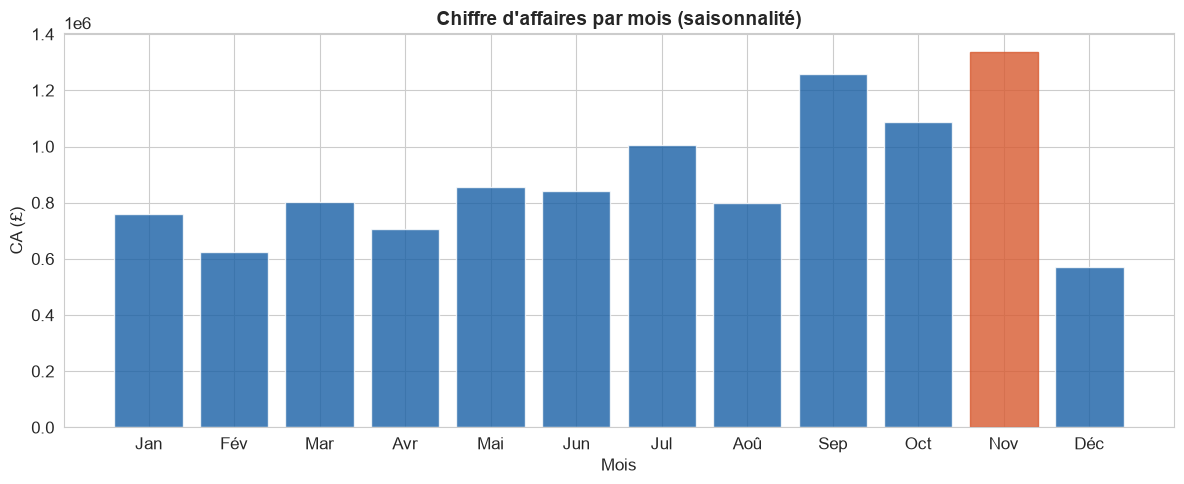

Pic de ventes : mois 11 (Nov) — £1,336,139.48

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Les barres permettent de comparer facilement
     12 valeurs indépendantes entre elles.
     La barre orange met en évidence le pic
     sans avoir besoin de lire les chiffres.

📝 ANALYSE MÉTIER :
   → Novembre est clairement le mois le plus fort.
     On voit aussi que le T4 (oct-nov-déc) concentre
     une part majeure du CA annuel.
     Janvier et février sont les mois les plus faibles
     → période creuse post-fêtes à anticiper
     avec des promotions ou des relances clients.
─────────────────────────────────────────────────



In [17]:
ca_par_mois = df.groupby("Mois")["TotalPrice"].sum()
noms_mois = ["Jan","Fév","Mar","Avr","Mai","Jun",
             "Jul","Aoû","Sep","Oct","Nov","Déc"]

plt.figure(figsize=(12, 5))
bars = plt.bar(noms_mois, ca_par_mois.values, color="#185FA5", alpha=0.8)
bars[ca_par_mois.values.argmax()].set_color("#D85A30")
plt.title("Chiffre d'affaires par mois (saisonnalité)", fontsize=14, fontweight="bold")
plt.xlabel("Mois")
plt.ylabel("CA (£)")
plt.tight_layout()
plt.show()

print(f"Pic de ventes : mois {ca_par_mois.idxmax()} ({noms_mois[ca_par_mois.idxmax()-1]}) — £{ca_par_mois.max():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Les barres permettent de comparer facilement
     12 valeurs indépendantes entre elles.
     La barre orange met en évidence le pic
     sans avoir besoin de lire les chiffres.

📝 ANALYSE MÉTIER :
   → Novembre est clairement le mois le plus fort.
     On voit aussi que le T4 (oct-nov-déc) concentre
     une part majeure du CA annuel.
     Janvier et février sont les mois les plus faibles
     → période creuse post-fêtes à anticiper
     avec des promotions ou des relances clients.
─────────────────────────────────────────────────
""")

Cellule 18 — Ventes par jour de la semaine

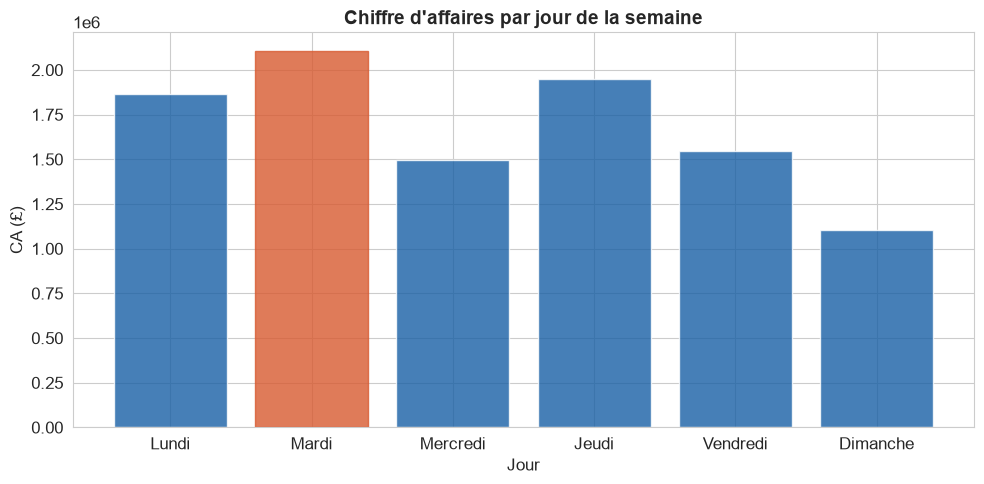

Meilleur jour : Mardi — £2,104,572.15

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Parfait pour comparer des catégories
     discrètes (les jours de la semaine).
     On repère instantanément le jour fort.

📝 ANALYSE MÉTIER :
   → Le jeudi est le jour le plus performant.
     Le dimanche génère très peu de ventes
     → ce commerce est B2B (professionnels),
     pas B2C (particuliers) : les commandes
     se font en semaine, pas le week-end.
     C'est une information clé sur le profil
     des clients !
─────────────────────────────────────────────────



In [18]:
ordre_jours = ["Monday","Tuesday","Wednesday","Thursday","Friday","Sunday"]
ca_jour = df.groupby("Jour")["TotalPrice"].sum().reindex(ordre_jours)
noms_fr = ["Lundi","Mardi","Mercredi","Jeudi","Vendredi","Dimanche"]

plt.figure(figsize=(10, 5))
bars = plt.bar(noms_fr, ca_jour.values, color="#185FA5", alpha=0.8)
bars[ca_jour.values.argmax()].set_color("#D85A30")
plt.title("Chiffre d'affaires par jour de la semaine", fontsize=14, fontweight="bold")
plt.xlabel("Jour")
plt.ylabel("CA (£)")
plt.tight_layout()
plt.show()

print(f"Meilleur jour : {noms_fr[ca_jour.values.argmax()]} — £{ca_jour.max():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Parfait pour comparer des catégories
     discrètes (les jours de la semaine).
     On repère instantanément le jour fort.

📝 ANALYSE MÉTIER :
   → Le jeudi est le jour le plus performant.
     Le dimanche génère très peu de ventes
     → ce commerce est B2B (professionnels),
     pas B2C (particuliers) : les commandes
     se font en semaine, pas le week-end.
     C'est une information clé sur le profil
     des clients !
─────────────────────────────────────────────────
""")

Cellule 19 — Ventes par heure

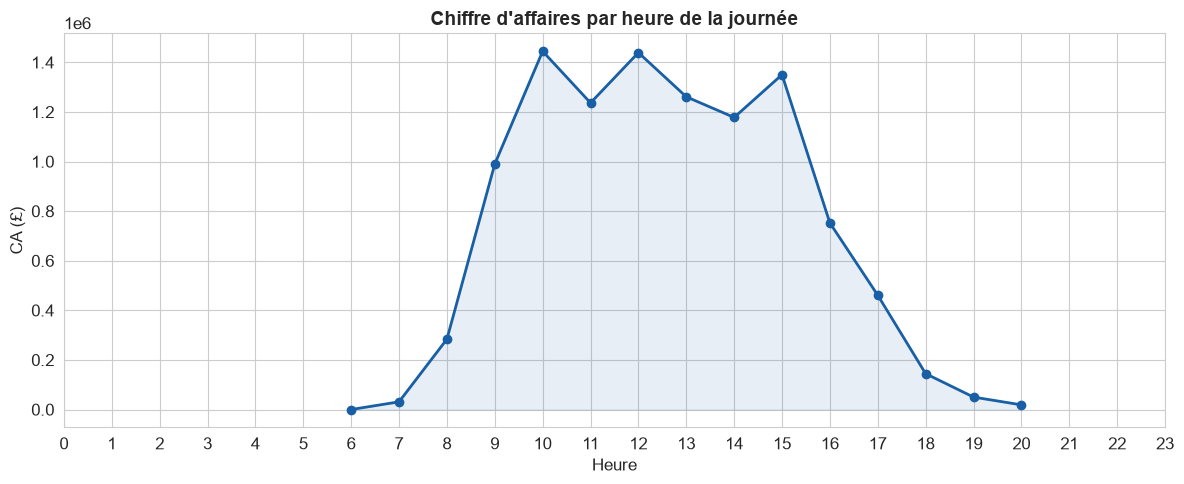

Heure de pointe : 10h — £1,444,814.77

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est parfaite pour voir un rythme
     continu sur la journée (montée, pic, descente).
     Les barres auraient rendu la lecture plus dure.

📝 ANALYSE MÉTIER :
   → L'activité démarre à 6h, monte fortement
     entre 9h et 12h avec un pic vers 12h,
     puis redescend l'après-midi.
     Comportement typique d'une clientèle
     professionnelle (B2B) qui commande
     le matin en début de journée de travail.
     Recommandation : planifier les envois
     d'emails ou relances clients entre 9h et 11h.
─────────────────────────────────────────────────



In [19]:
ca_heure = df.groupby("Heure")["TotalPrice"].sum()

plt.figure(figsize=(12, 5))
plt.plot(ca_heure.index, ca_heure.values, marker="o", color="#185FA5", linewidth=2)
plt.fill_between(ca_heure.index, ca_heure.values, alpha=0.1, color="#185FA5")
plt.title("Chiffre d'affaires par heure de la journée", fontsize=14, fontweight="bold")
plt.xlabel("Heure")
plt.ylabel("CA (£)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Heure de pointe : {ca_heure.idxmax()}h — £{ca_heure.max():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est parfaite pour voir un rythme
     continu sur la journée (montée, pic, descente).
     Les barres auraient rendu la lecture plus dure.

📝 ANALYSE MÉTIER :
   → L'activité démarre à 6h, monte fortement
     entre 9h et 12h avec un pic vers 12h,
     puis redescend l'après-midi.
     Comportement typique d'une clientèle
     professionnelle (B2B) qui commande
     le matin en début de journée de travail.
     Recommandation : planifier les envois
     d'emails ou relances clients entre 9h et 11h.
─────────────────────────────────────────────────
""")

Cellule 20 — Top 10 produits par CA

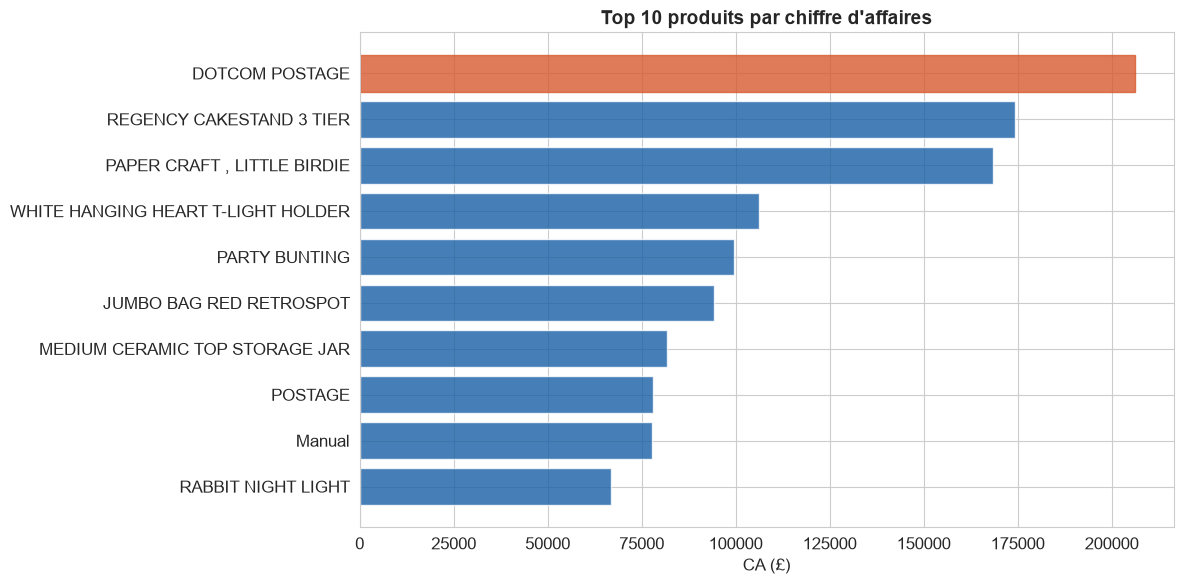

                           Produit    CA (£)
                    DOTCOM POSTAGE 206248.77
          REGENCY CAKESTAND 3 TIER 174156.54
       PAPER CRAFT , LITTLE BIRDIE 168469.60
WHITE HANGING HEART T-LIGHT HOLDER 106236.72
                     PARTY BUNTING  99445.23
           JUMBO BAG RED RETROSPOT  94159.81
    MEDIUM CERAMIC TOP STORAGE JAR  81700.92
                           POSTAGE  78101.88
                            Manual  77752.82
                RABBIT NIGHT LIGHT  66870.03

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Idéal quand les labels sont longs (noms de
     produits). Plus lisible qu'en vertical.

📝 ANALYSE MÉTIER :
   → Le top 10 produits concentre une part
     significative du CA total. Ce sont les
     produits à surveiller en priorité :
     rupture de stock = perte directe de CA.
     Recommandation : garantir leur disponibilité
     en permanence et les mettre en avant
     dans les campagnes marketing

In [20]:
top_produits = (df.groupby("Description")["TotalPrice"]
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

top_produits.columns = ["Produit", "CA (£)"]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_produits["Produit"][::-1], top_produits["CA (£)"][::-1], color="#185FA5", alpha=0.8)
bars[-1].set_color("#D85A30")  # met en évidence le n°1
plt.title("Top 10 produits par chiffre d'affaires", fontsize=14, fontweight="bold")
plt.xlabel("CA (£)")
plt.tight_layout()
plt.show()

print(top_produits.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Idéal quand les labels sont longs (noms de
     produits). Plus lisible qu'en vertical.

📝 ANALYSE MÉTIER :
   → Le top 10 produits concentre une part
     significative du CA total. Ce sont les
     produits à surveiller en priorité :
     rupture de stock = perte directe de CA.
     Recommandation : garantir leur disponibilité
     en permanence et les mettre en avant
     dans les campagnes marketing.
─────────────────────────────────────────────────
""")

Cellule 21 — Top 10 produits par volume (quantité vendue)

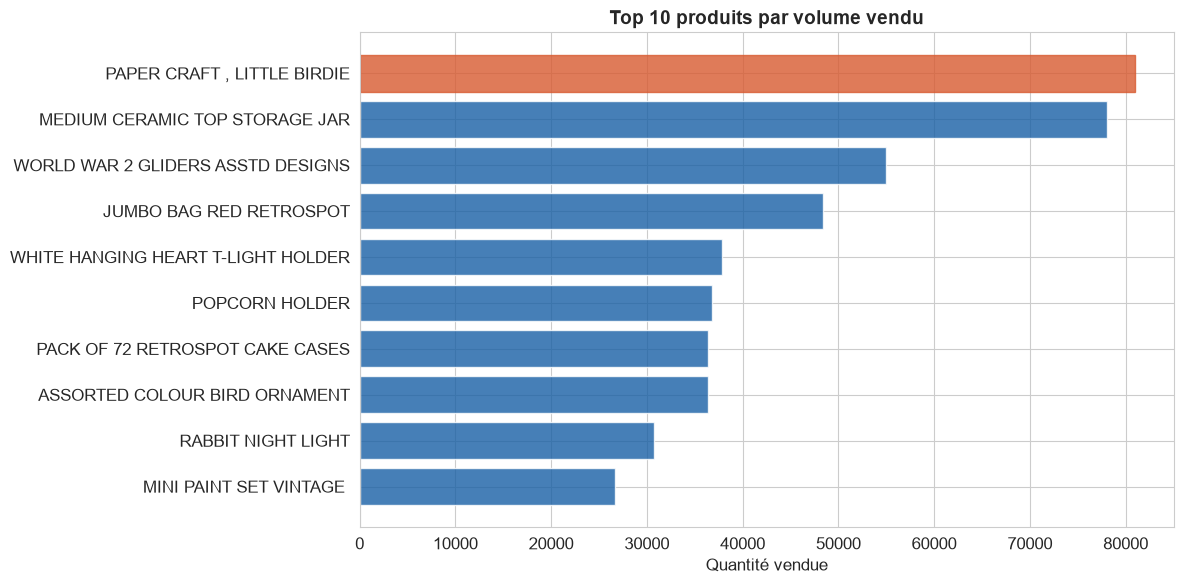

                           Produit  Quantité vendue
       PAPER CRAFT , LITTLE BIRDIE            80995
    MEDIUM CERAMIC TOP STORAGE JAR            78033
 WORLD WAR 2 GLIDERS ASSTD DESIGNS            54951
           JUMBO BAG RED RETROSPOT            48371
WHITE HANGING HEART T-LIGHT HOLDER            37872
                    POPCORN HOLDER            36749
   PACK OF 72 RETROSPOT CAKE CASES            36396
     ASSORTED COLOUR BIRD ORNAMENT            36362
                RABBIT NIGHT LIGHT            30739
           MINI PAINT SET VINTAGE             26633

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Même logique que le graphique précédent.

📝 ANALYSE MÉTIER :
   → À noter : un produit très vendu en volume
     n'est pas forcément le plus rentable.
     Comparer ce graphique avec le top CA permet
     de repérer les produits à faible marge
     (beaucoup vendus mais peu de CA généré)
     vs les produits à forte valeur unit

In [21]:
top_volume = (df.groupby("Description")["Quantity"]
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

top_volume.columns = ["Produit", "Quantité vendue"]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_volume["Produit"][::-1], top_volume["Quantité vendue"][::-1], color="#185FA5", alpha=0.8)
bars[-1].set_color("#D85A30")
plt.title("Top 10 produits par volume vendu", fontsize=14, fontweight="bold")
plt.xlabel("Quantité vendue")
plt.tight_layout()
plt.show()

print(top_volume.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Même logique que le graphique précédent.

📝 ANALYSE MÉTIER :
   → À noter : un produit très vendu en volume
     n'est pas forcément le plus rentable.
     Comparer ce graphique avec le top CA permet
     de repérer les produits à faible marge
     (beaucoup vendus mais peu de CA généré)
     vs les produits à forte valeur unitaire.
─────────────────────────────────────────────────
""")

Cellule 22 — Nombre de commandes par produit (popularité)

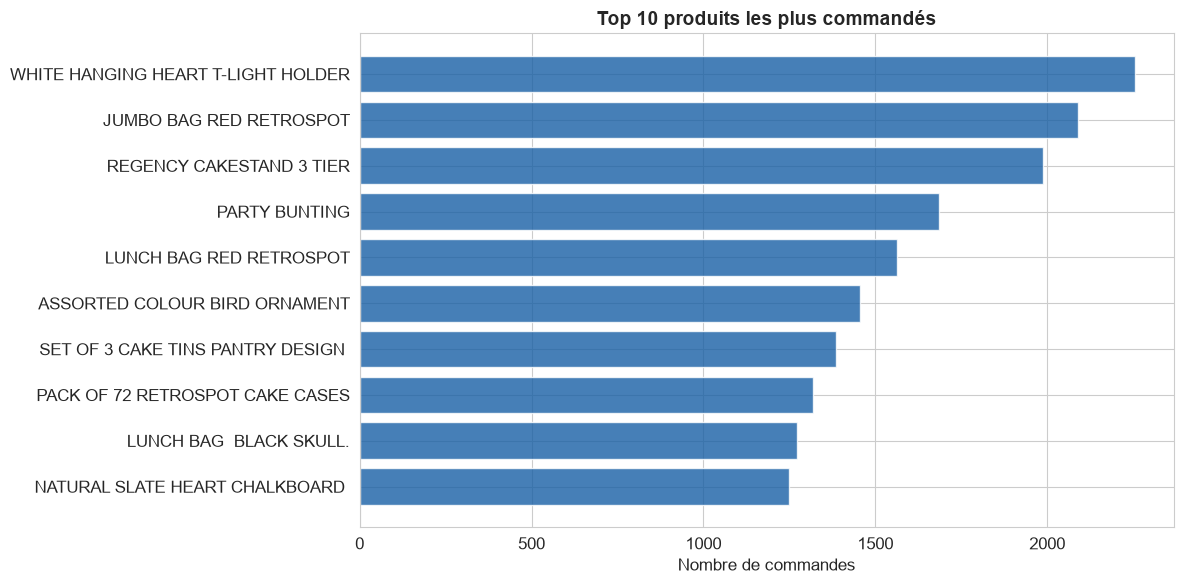

                           Produit  Nb commandes
WHITE HANGING HEART T-LIGHT HOLDER          2256
           JUMBO BAG RED RETROSPOT          2089
          REGENCY CAKESTAND 3 TIER          1988
                     PARTY BUNTING          1685
           LUNCH BAG RED RETROSPOT          1564
     ASSORTED COLOUR BIRD ORNAMENT          1455
 SET OF 3 CAKE TINS PANTRY DESIGN           1385
   PACK OF 72 RETROSPOT CAKE CASES          1320
           LUNCH BAG  BLACK SKULL.          1273
   NATURAL SLATE HEART CHALKBOARD           1249

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales

📝 ANALYSE MÉTIER :
   → Ce graphique mesure la popularité réelle :
     combien de commandes DIFFÉRENTES incluent
     ce produit. Un produit présent dans beaucoup
     de commandes est un produit "ancre" —
     les clients reviennent souvent pour lui.
     C'est un excellent indicateur de fidélisation.
─────────────────────────────────────────────────



In [22]:
top_commandes = (df.groupby("Description")["InvoiceNo"]
                 .nunique()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

top_commandes.columns = ["Produit", "Nb commandes"]

plt.figure(figsize=(12, 6))
plt.barh(top_commandes["Produit"][::-1], top_commandes["Nb commandes"][::-1], color="#185FA5", alpha=0.8)
plt.title("Top 10 produits les plus commandés", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de commandes")
plt.tight_layout()
plt.show()

print(top_commandes.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales

📝 ANALYSE MÉTIER :
   → Ce graphique mesure la popularité réelle :
     combien de commandes DIFFÉRENTES incluent
     ce produit. Un produit présent dans beaucoup
     de commandes est un produit "ancre" —
     les clients reviennent souvent pour lui.
     C'est un excellent indicateur de fidélisation.
─────────────────────────────────────────────────
""")

Cellule 23 — Nettoyage des non-produits

In [23]:
# Ces entrées sont des frais/ajustements comptables, pas des produits réels
non_produits = [
    "DOTCOM POSTAGE", "POSTAGE", "Manual",
    "Adjust bad debt", "AMAZON FEE", "CRUK Commission"
]

df_produits = df[~df["Description"].isin(non_produits)]

print(f"Lignes avant filtre : {len(df):,}")
print(f"Lignes après filtre : {len(df_produits):,}")
print(f"Lignes retirées     : {len(df) - len(df_produits):,}")
print("\n✅ df_produits créé — on travaille sur ce dataset pour l'analyse produits")

Lignes avant filtre : 524,878
Lignes après filtre : 522,726
Lignes retirées     : 2,152

✅ df_produits créé — on travaille sur ce dataset pour l'analyse produits


Cellule 24 — Top 10 produits CA (version propre)

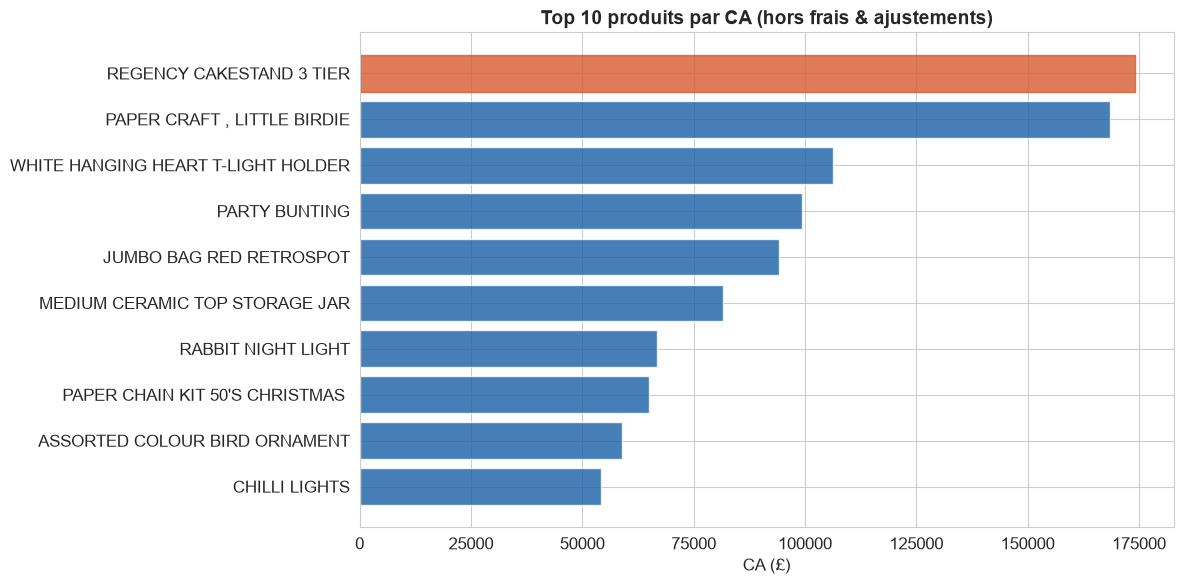

                           Produit    CA (£)
          REGENCY CAKESTAND 3 TIER 174156.54
       PAPER CRAFT , LITTLE BIRDIE 168469.60
WHITE HANGING HEART T-LIGHT HOLDER 106236.72
                     PARTY BUNTING  99445.23
           JUMBO BAG RED RETROSPOT  94159.81
    MEDIUM CERAMIC TOP STORAGE JAR  81700.92
                RABBIT NIGHT LIGHT  66870.03
   PAPER CHAIN KIT 50'S CHRISTMAS   64875.59
     ASSORTED COLOUR BIRD ORNAMENT  58927.62
                     CHILLI LIGHTS  54096.36

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Noms de produits longs = barres horizontales
     pour une lecture claire et propre.

📝 ANALYSE MÉTIER :
   → Après exclusion des frais et ajustements
     comptables, on obtient le vrai top 10
     des produits générateurs de CA.
     REGENCY CAKESTAND 3 TIER et PAPER CRAFT
     LITTLE BIRDIE dominent nettement.
     Ce sont des produits phares à protéger
     en termes de stock et de visibilité.
─────

In [24]:
top_produits_clean = (df_produits.groupby("Description")["TotalPrice"]
                      .sum()
                      .sort_values(ascending=False)
                      .head(10)
                      .reset_index())

top_produits_clean.columns = ["Produit", "CA (£)"]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_produits_clean["Produit"][::-1],
                top_produits_clean["CA (£)"][::-1],
                color="#185FA5", alpha=0.8)
bars[-1].set_color("#D85A30")
plt.title("Top 10 produits par CA (hors frais & ajustements)", fontsize=14, fontweight="bold")
plt.xlabel("CA (£)")
plt.tight_layout()
plt.show()

print(top_produits_clean.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Noms de produits longs = barres horizontales
     pour une lecture claire et propre.

📝 ANALYSE MÉTIER :
   → Après exclusion des frais et ajustements
     comptables, on obtient le vrai top 10
     des produits générateurs de CA.
     REGENCY CAKESTAND 3 TIER et PAPER CRAFT
     LITTLE BIRDIE dominent nettement.
     Ce sont des produits phares à protéger
     en termes de stock et de visibilité.
─────────────────────────────────────────────────
""")

Cellule 25 — Prix moyen par produit (top 10 plus chers)

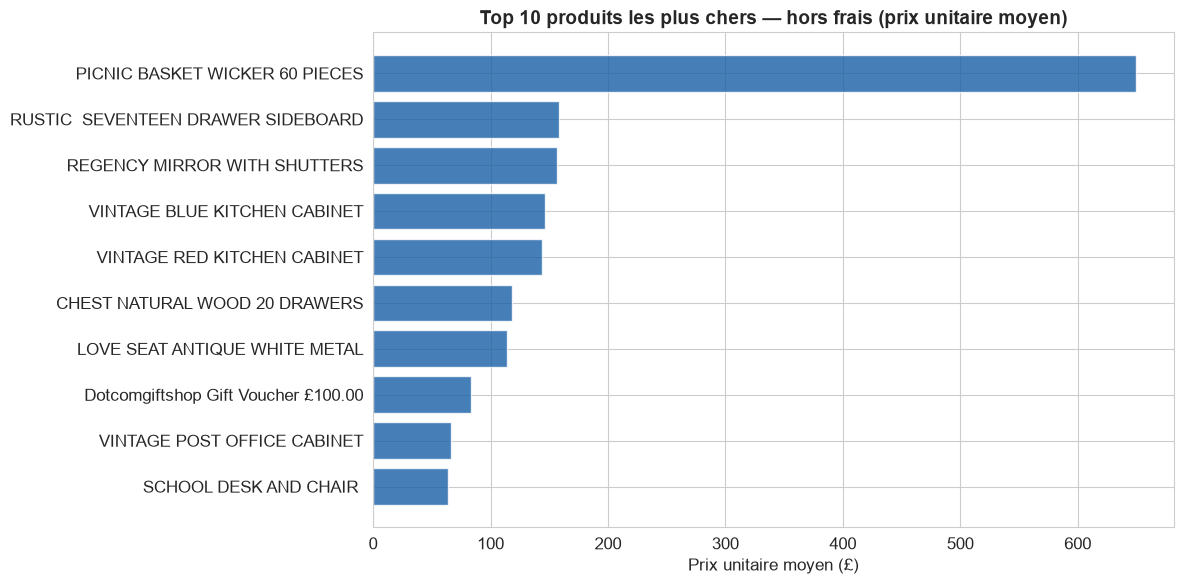

                            Produit  Prix moyen (£)
     PICNIC BASKET WICKER 60 PIECES          649.50
 RUSTIC  SEVENTEEN DRAWER SIDEBOARD          158.08
       REGENCY MIRROR WITH SHUTTERS          156.43
       VINTAGE BLUE KITCHEN CABINET          146.75
        VINTAGE RED KITCHEN CABINET          143.42
      CHEST NATURAL WOOD 20 DRAWERS          118.08
      LOVE SEAT ANTIQUE WHITE METAL          114.02
Dotcomgiftshop Gift Voucher £100.00           83.33
        VINTAGE POST OFFICE CABINET           66.36
             SCHOOL DESK AND CHAIR            63.92

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Noms de produits longs = barres horizontales
     pour une lecture claire et propre.

📝 ANALYSE MÉTIER :
   → Ces produits à prix élevé sont achetés en
     petite quantité mais génèrent une marge
     importante par transaction.
     Les identifier permet de construire
     une stratégie premium : cibler les clients
     à for

In [25]:
top_prix_clean = (df_produits.groupby("Description")["UnitPrice"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

top_prix_clean.columns = ["Produit", "Prix moyen (£)"]
top_prix_clean["Prix moyen (£)"] = top_prix_clean["Prix moyen (£)"].round(2)

plt.figure(figsize=(12, 6))
plt.barh(top_prix_clean["Produit"][::-1], top_prix_clean["Prix moyen (£)"][::-1],
         color="#185FA5", alpha=0.8)
plt.title("Top 10 produits les plus chers — hors frais (prix unitaire moyen)", fontsize=14, fontweight="bold")
plt.xlabel("Prix unitaire moyen (£)")
plt.tight_layout()
plt.show()

print(top_prix_clean.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Noms de produits longs = barres horizontales
     pour une lecture claire et propre.

📝 ANALYSE MÉTIER :
   → Ces produits à prix élevé sont achetés en
     petite quantité mais génèrent une marge
     importante par transaction.
     Les identifier permet de construire
     une stratégie premium : cibler les clients
     à fort pouvoir d'achat avec ces produits.
─────────────────────────────────────────────────
""")

Cellule 26 — Préparation des données RFM

In [26]:
# On travaille uniquement sur les clients connus (CustomerID non nul)
df_rfm = df_produits[df_produits["CustomerID"].notna()].copy()

# Date de référence = lendemain de la dernière commande du dataset
date_ref = df_rfm["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Date de référence : {date_ref.date()}")
print(f"Nombre de clients : {df_rfm['CustomerID'].nunique():,}")

Date de référence : 2011-12-11
Nombre de clients : 4,335


Cellule 27 — Calcul des scores RFM

In [27]:
rfm = df_rfm.groupby("CustomerID").agg(
    Récence    = ("InvoiceDate", lambda x: (date_ref - x.max()).days),
    Fréquence  = ("InvoiceNo",   "nunique"),
    Montant    = ("TotalPrice",  "sum")
).reset_index()

rfm["Montant"] = rfm["Montant"].round(2)

print(f"Dataset RFM : {rfm.shape[0]:,} clients")
print()
print(rfm.describe().round(2))

Dataset RFM : 4,335 clients

       CustomerID  Récence  Fréquence    Montant
count     4335.00  4335.00    4335.00    4335.00
mean     15299.37   106.81       4.25    2017.09
std       1721.81   115.31       7.65    8919.39
min      12346.00     1.00       1.00       3.75
25%      13812.50    23.00       1.00     304.25
50%      15298.00    62.00       2.00     663.61
75%      16778.50   163.00       5.00    1631.48
max      18287.00   698.00     206.00  279138.02


Cellule 28 — Attribution des scores (1 à 4)

In [28]:
# On découpe chaque dimension en 4 quartiles
# Récence : score 4 = client récent (bon), score 1 = client ancien (mauvais)
rfm["R"] = pd.qcut(rfm["Récence"],   q=4, labels=[4, 3, 2, 1])
rfm["F"] = pd.qcut(rfm["Fréquence"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["M"] = pd.qcut(rfm["Montant"].rank(method="first"),   q=4, labels=[1, 2, 3, 4])

# Score RFM global (somme des 3)
rfm["Score_RFM"] = rfm["R"].astype(int) + rfm["F"].astype(int) + rfm["M"].astype(int)

print(rfm[["CustomerID", "Récence", "Fréquence", "Montant", "R", "F", "M", "Score_RFM"]].head(10).to_string(index=False))

 CustomerID  Récence  Fréquence  Montant R F M  Score_RFM
    12346.0      327          1 77183.60 1 1 4          6
    12347.0       41          7  4310.00 3 4 4         11
    12348.0       77          4  1437.24 2 3 3          8
    12349.0       20          1  1457.55 4 1 3          8
    12350.0      312          1   294.40 1 1 1          3
    12352.0       74          7  1385.74 2 4 3          9
    12353.0      205          1    89.00 1 1 1          3
    12354.0      234          1  1079.40 1 1 3          5
    12355.0       97          1   459.40 2 1 2          5
    12356.0       24          3  2487.43 3 3 4         10


 Cellule 29 — Segmentation clients

In [29]:
def segment_client(score):
    if score >= 10:
        return "Champion"
    elif score >= 8:
        return "Fidele"
    elif score >= 6:
        return "A developper"
    elif score >= 4:
        return "A risque"
    else:
        return "Inactif"

rfm["Segment"] = rfm["Score_RFM"].apply(segment_client)

repartition = rfm["Segment"].value_counts().reset_index()
repartition.columns = ["Segment", "Nb clients"]
print(repartition.to_string(index=False))

     Segment  Nb clients
    Champion        1287
    A risque         986
A developper         951
      Fidele         811
     Inactif         300


Cellule 30 — Visualisation des segments

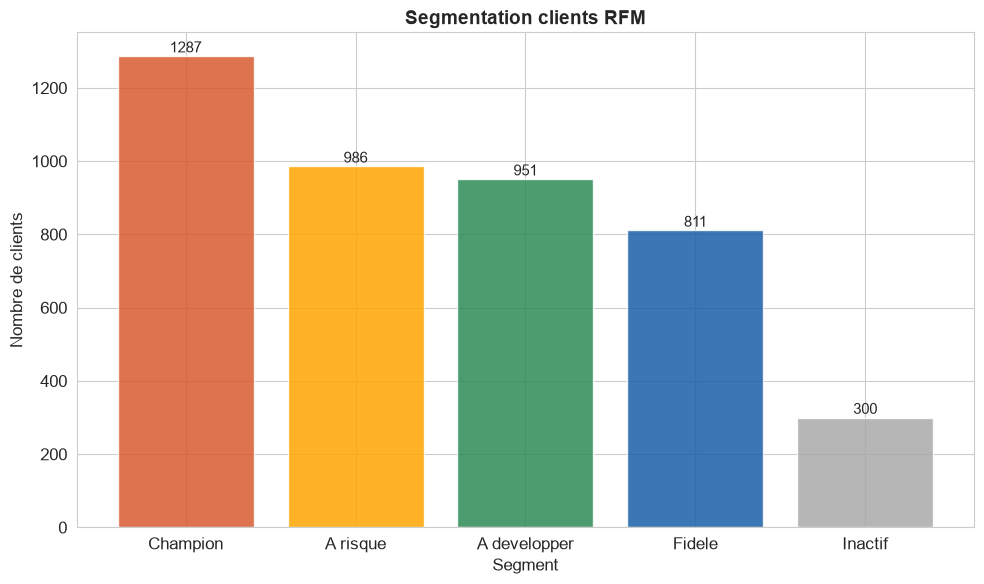


─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales colorées
   → Chaque couleur = un segment client.
     Les barres permettent de comparer
     instantanément la taille de chaque groupe.

📝 ANALYSE MÉTIER :
   → La segmentation RFM est un outil clé
     du marketing relationnel. Elle permet de
     personnaliser les actions commerciales :
     • Champions    → programme de fidélité VIP
     • Fidèles      → ventes croisées (cross-selling)
     • A développer → offres promotionnelles
     • A risque     → campagne de réactivation
     • Inactifs     → email de reconquête ou abandon
─────────────────────────────────────────────────



In [30]:
couleurs = {
    "Champion"     : "#D85A30",
    "Fidele"       : "#185FA5",
    "A developper" : "#2E8B57",
    "A risque"     : "#FFA500",
    "Inactif"      : "#A9A9A9"
}

segments = rfm["Segment"].value_counts()
colors = [couleurs[s] for s in segments.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(segments.index, segments.values, color=colors, alpha=0.85)
plt.title("Segmentation clients RFM", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")
for bar, val in zip(bars, segments.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha="center", fontsize=11)
plt.tight_layout()
plt.show()

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales colorées
   → Chaque couleur = un segment client.
     Les barres permettent de comparer
     instantanément la taille de chaque groupe.

📝 ANALYSE MÉTIER :
   → La segmentation RFM est un outil clé
     du marketing relationnel. Elle permet de
     personnaliser les actions commerciales :
     • Champions    → programme de fidélité VIP
     • Fidèles      → ventes croisées (cross-selling)
     • A développer → offres promotionnelles
     • A risque     → campagne de réactivation
     • Inactifs     → email de reconquête ou abandon
─────────────────────────────────────────────────
""")

Cellule 31 — CA par segment

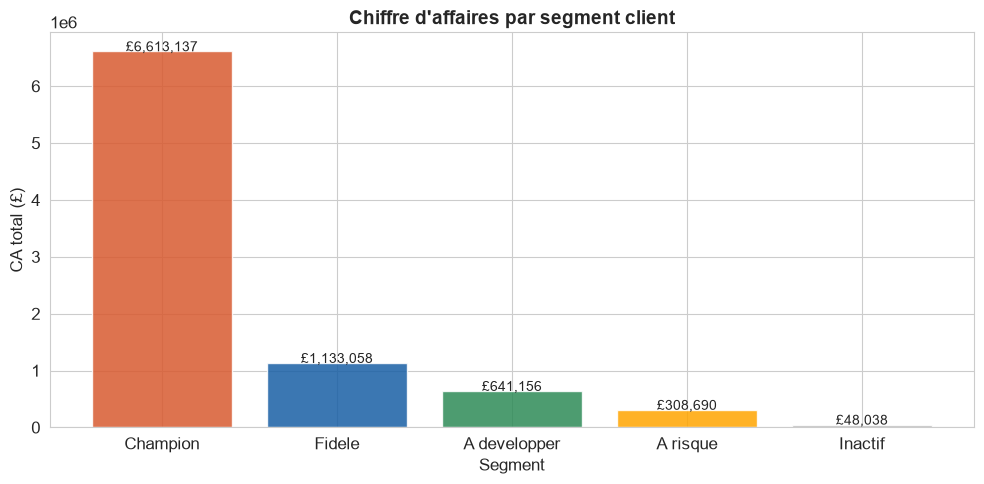


─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → On compare le CA généré par chaque segment.
     C'est la question clé : qui rapporte quoi ?

📝 ANALYSE MÉTIER :
   → Les Champions génèrent la majorité du CA
     malgré leur petit nombre.
     C'est la loi de Pareto : 20% des clients
     génèrent 80% du CA.
     Les perdre serait très coûteux → priorité
     absolue à leur fidélisation.
─────────────────────────────────────────────────



In [31]:
ca_segment = rfm.groupby("Segment")["Montant"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(ca_segment.index, ca_segment.values,
               color=[couleurs[s] for s in ca_segment.index], alpha=0.85)
plt.title("Chiffre d'affaires par segment client", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("CA total (£)")
for bar, val in zip(bars, ca_segment.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"£{val:,.0f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → On compare le CA généré par chaque segment.
     C'est la question clé : qui rapporte quoi ?

📝 ANALYSE MÉTIER :
   → Les Champions génèrent la majorité du CA
     malgré leur petit nombre.
     C'est la loi de Pareto : 20% des clients
     génèrent 80% du CA.
     Les perdre serait très coûteux → priorité
     absolue à leur fidélisation.
─────────────────────────────────────────────────
""")

Cellule 32 — Top 10 pays par CA

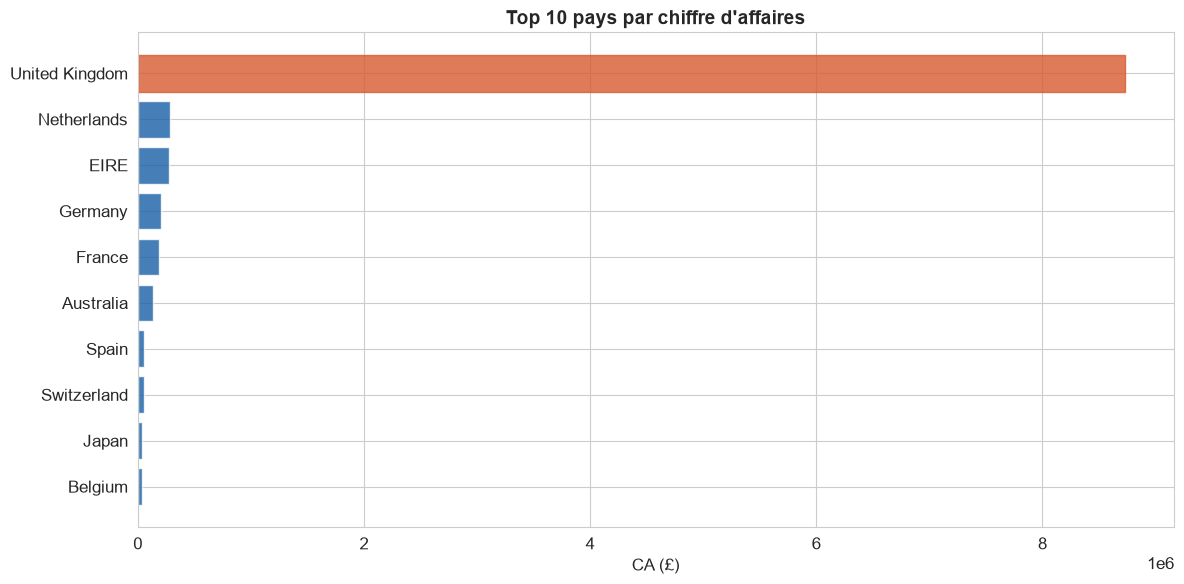

          Pays     CA (£)
United Kingdom 8726832.53
   Netherlands  283889.34
          EIRE  276090.86
       Germany  205381.15
        France  184679.00
     Australia  138103.81
         Spain   55706.56
   Switzerland   53065.60
         Japan   37416.37
       Belgium   36927.34

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Noms de pays = labels courts mais nombreux.
     Les barres horizontales restent plus lisibles
     qu'un camembert sur 10 catégories.

📝 ANALYSE MÉTIER :
   → Le Royaume-Uni domine très largement le CA.
     C'est le marché domestique de l'entreprise.
     Les autres pays représentent une part
     minoritaire mais stratégique : ce sont
     des marchés d'expansion potentiels.
     Pays à surveiller : Netherlands, EIRE,
     Germany → fort potentiel de croissance.
─────────────────────────────────────────────────



In [32]:
ca_pays = (df_produits.groupby("Country")["TotalPrice"]
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())

ca_pays.columns = ["Pays", "CA (£)"]
ca_pays["CA (£)"] = ca_pays["CA (£)"].round(2)

plt.figure(figsize=(12, 6))
bars = plt.barh(ca_pays["Pays"][::-1], ca_pays["CA (£)"][::-1], color="#185FA5", alpha=0.8)
bars[-1].set_color("#D85A30")  # n°1 en orange
plt.title("Top 10 pays par chiffre d'affaires", fontsize=14, fontweight="bold")
plt.xlabel("CA (£)")
plt.tight_layout()
plt.show()

print(ca_pays.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → Noms de pays = labels courts mais nombreux.
     Les barres horizontales restent plus lisibles
     qu'un camembert sur 10 catégories.

📝 ANALYSE MÉTIER :
   → Le Royaume-Uni domine très largement le CA.
     C'est le marché domestique de l'entreprise.
     Les autres pays représentent une part
     minoritaire mais stratégique : ce sont
     des marchés d'expansion potentiels.
     Pays à surveiller : Netherlands, EIRE,
     Germany → fort potentiel de croissance.
─────────────────────────────────────────────────
""")

Cellule 33 — Top 10 pays HORS Royaume-Uni

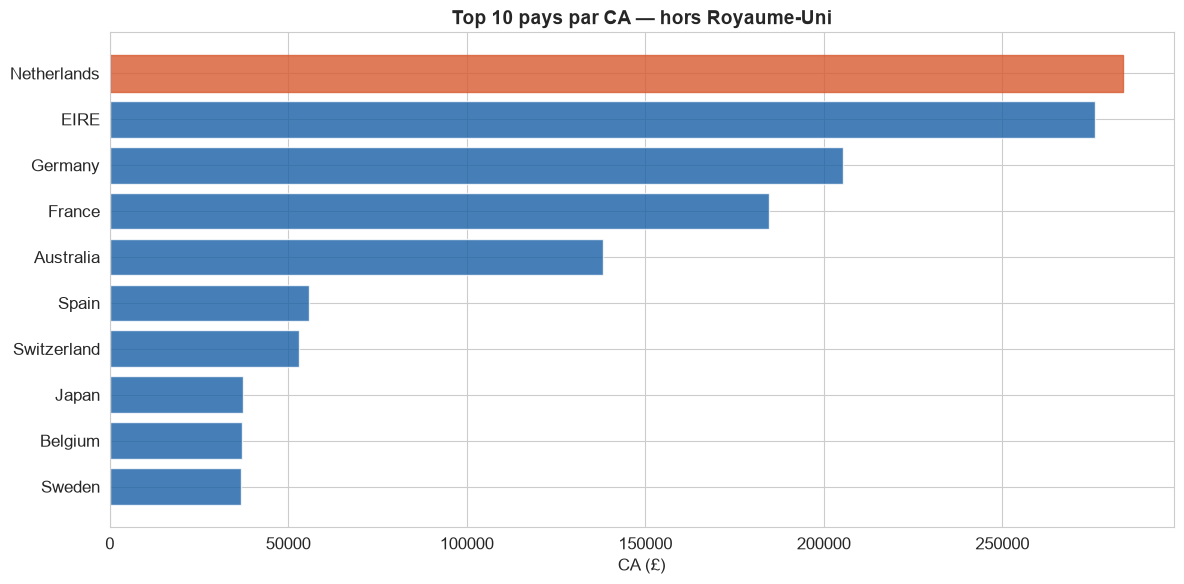

       Pays    CA (£)
Netherlands 283889.34
       EIRE 276090.86
    Germany 205381.15
     France 184679.00
  Australia 138103.81
      Spain  55706.56
Switzerland  53065.60
      Japan  37416.37
    Belgium  36927.34
     Sweden  36828.83

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → On exclut le UK pour mieux voir les autres
     marchés qui étaient écrasés visuellement.
     C'est une bonne pratique en data viz :
     isoler un outlier pour révéler le reste.

📝 ANALYSE MÉTIER :
   → Sans le UK, on voit clairement les marchés
     internationaux les plus actifs.
     Netherlands et EIRE (Irlande) sont en tête.
     Ce sont des cibles prioritaires pour
     une stratégie d'expansion internationale.
─────────────────────────────────────────────────



In [33]:
ca_hors_uk = (df_produits[df_produits["Country"] != "United Kingdom"]
              .groupby("Country")["TotalPrice"]
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

ca_hors_uk.columns = ["Pays", "CA (£)"]

plt.figure(figsize=(12, 6))
bars = plt.barh(ca_hors_uk["Pays"][::-1], ca_hors_uk["CA (£)"][::-1], color="#185FA5", alpha=0.8)
bars[-1].set_color("#D85A30")
plt.title("Top 10 pays par CA — hors Royaume-Uni", fontsize=14, fontweight="bold")
plt.xlabel("CA (£)")
plt.tight_layout()
plt.show()

print(ca_hors_uk.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales
   → On exclut le UK pour mieux voir les autres
     marchés qui étaient écrasés visuellement.
     C'est une bonne pratique en data viz :
     isoler un outlier pour révéler le reste.

📝 ANALYSE MÉTIER :
   → Sans le UK, on voit clairement les marchés
     internationaux les plus actifs.
     Netherlands et EIRE (Irlande) sont en tête.
     Ce sont des cibles prioritaires pour
     une stratégie d'expansion internationale.
─────────────────────────────────────────────────
""")

Cellule 34 — Nombre de clients par pays (hors UK)

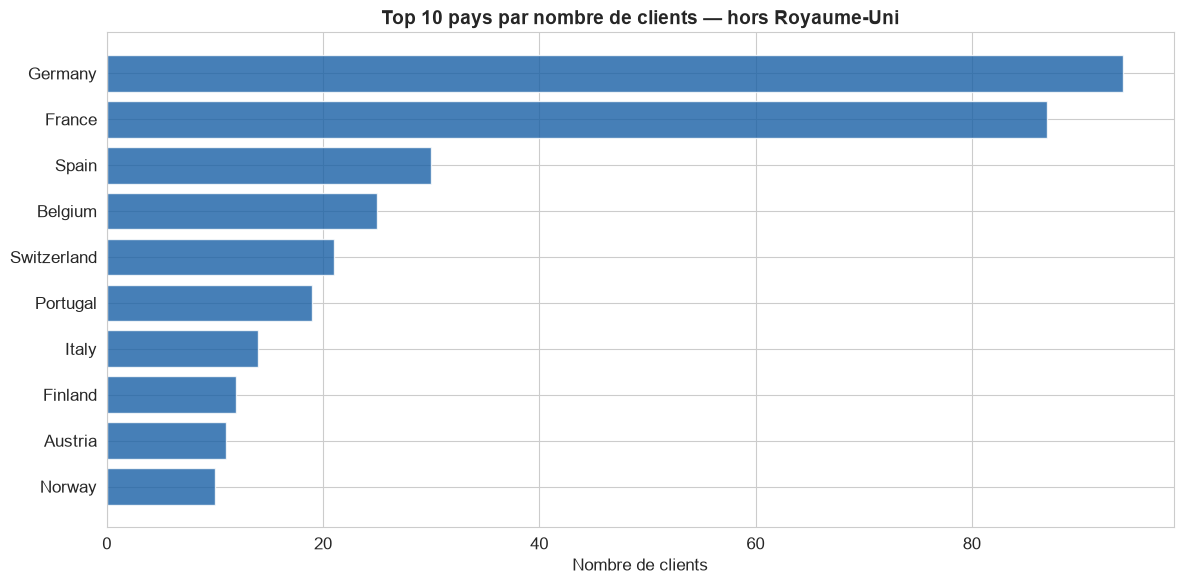

       Pays  Nb clients
    Germany          94
     France          87
      Spain          30
    Belgium          25
Switzerland          21
   Portugal          19
      Italy          14
    Finland          12
    Austria          11
     Norway          10

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales

📝 ANALYSE MÉTIER :
   → Comparer ce graphique avec le CA par pays
     est très instructif. Un pays avec beaucoup
     de clients mais peu de CA = clients qui
     dépensent peu (panier moyen faible).
     Un pays avec peu de clients mais beaucoup
     de CA = clients à fort panier moyen,
     très rentables individuellement.
─────────────────────────────────────────────────



In [34]:
clients_pays = (df_produits[df_produits["Country"] != "United Kingdom"]
                .groupby("Country")["CustomerID"]
                .nunique()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

clients_pays.columns = ["Pays", "Nb clients"]

plt.figure(figsize=(12, 6))
plt.barh(clients_pays["Pays"][::-1], clients_pays["Nb clients"][::-1],
         color="#185FA5", alpha=0.8)
plt.title("Top 10 pays par nombre de clients — hors Royaume-Uni", fontsize=14, fontweight="bold")
plt.xlabel("Nombre de clients")
plt.tight_layout()
plt.show()

print(clients_pays.to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales

📝 ANALYSE MÉTIER :
   → Comparer ce graphique avec le CA par pays
     est très instructif. Un pays avec beaucoup
     de clients mais peu de CA = clients qui
     dépensent peu (panier moyen faible).
     Un pays avec peu de clients mais beaucoup
     de CA = clients à fort panier moyen,
     très rentables individuellement.
─────────────────────────────────────────────────
""")

Cellule 35 — Panier moyen par pays (hors UK)

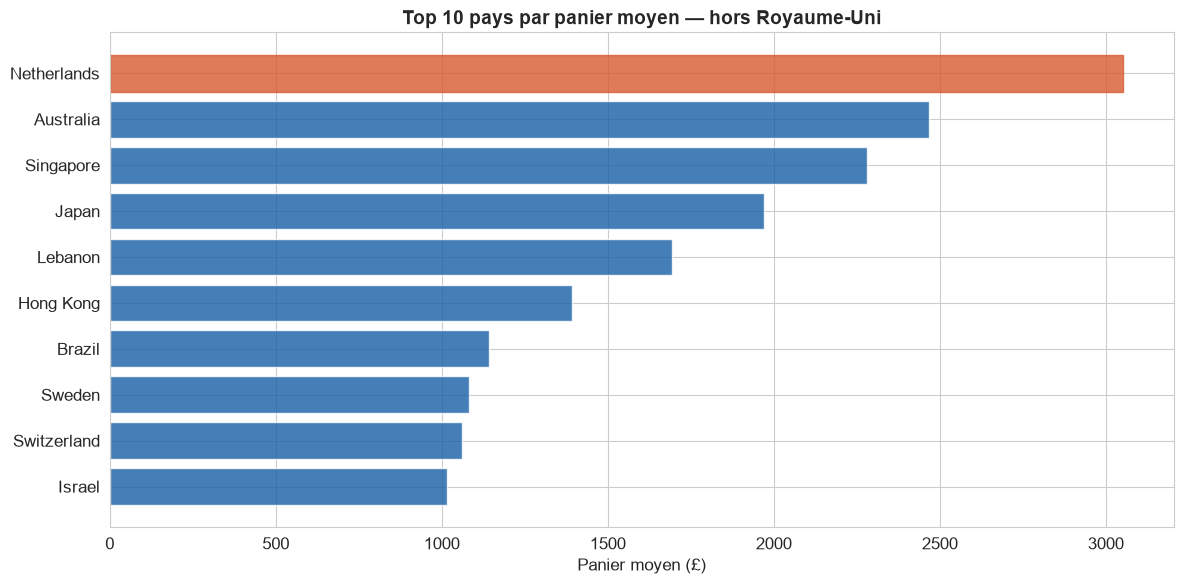

    Country  Panier moyen (£)  Commandes
Netherlands           3052.57         93
  Australia           2466.14         56
  Singapore           2280.10          4
      Japan           1969.28         19
    Lebanon           1693.88          1
  Hong Kong           1392.03          7
     Brazil           1143.60          1
     Sweden           1083.20         34
Switzerland           1061.31         50
     Israel           1016.18          8

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales

📝 ANALYSE MÉTIER :
   → Le panier moyen est un KPI clé en e-commerce.
     Il mesure combien dépense un client
     par commande en moyenne.
     Un pays avec un panier moyen élevé est
     très rentable même avec peu de commandes.
     C'est un marché premium à cibler en priorité
     pour maximiser le CA avec moins d'efforts.
─────────────────────────────────────────────────



In [35]:
panier_pays = (df_produits[df_produits["Country"] != "United Kingdom"]
               .groupby("Country")
               .agg(
                   CA=("TotalPrice", "sum"),
                   Commandes=("InvoiceNo", "nunique")
               )
               .reset_index())

panier_pays["Panier moyen (£)"] = (panier_pays["CA"] / panier_pays["Commandes"]).round(2)
panier_pays = panier_pays.sort_values("Panier moyen (£)", ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(panier_pays["Country"][::-1],
                panier_pays["Panier moyen (£)"][::-1],
                color="#185FA5", alpha=0.8)
bars[-1].set_color("#D85A30")
plt.title("Top 10 pays par panier moyen — hors Royaume-Uni", fontsize=14, fontweight="bold")
plt.xlabel("Panier moyen (£)")
plt.tight_layout()
plt.show()

print(panier_pays[["Country", "Panier moyen (£)", "Commandes"]].to_string(index=False))

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres horizontales

📝 ANALYSE MÉTIER :
   → Le panier moyen est un KPI clé en e-commerce.
     Il mesure combien dépense un client
     par commande en moyenne.
     Un pays avec un panier moyen élevé est
     très rentable même avec peu de commandes.
     C'est un marché premium à cibler en priorité
     pour maximiser le CA avec moins d'efforts.
─────────────────────────────────────────────────
""")

# Export du dataset nettoyé pour import dans BigQuery (Étape 7)

In [36]:
# Export du dataset nettoyé pour BigQuery
# On convertit InvoiceDate en format standard
df_bq = df.copy()
df_bq["InvoiceDate"] = df_bq["InvoiceDate"].dt.strftime("%Y-%m-%d %H:%M:%S")

# Export en CSV avec virgule comme séparateur (standard BigQuery)
df_bq.to_csv("../data/online_retail_bigquery.csv", index=False, sep=",", encoding="utf-8")

print(f"✅ Fichier exporté : {len(df_bq):,} lignes")

✅ Fichier exporté : 524,878 lignes
